In [ ]:
import os, math, json, random, contextlib
from pathlib import Path
from typing import List, Tuple, Dict, Any

import numpy as np
import pandas as pd
from PIL import Image, ImageDraw

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
    f1_score, accuracy_score, confusion_matrix, classification_report
)

import matplotlib.pyplot as plt
from tqdm import tqdm

if torch.backends.mps.is_available():
    DEVICE = "mps"
elif torch.cuda.is_available():
    DEVICE = "cuda"
else:
    DEVICE = "cpu"

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if DEVICE == "cuda":
    torch.cuda.manual_seed_all(SEED)

BASE_DIR       = Path(".")
PATCH_DIR      = BASE_DIR / "patches"                
PATCHES_JSON   = BASE_DIR / "patches_bbox.json"     
IMG_DIRS       = [BASE_DIR / f"images{i}" for i in range(7)] + [BASE_DIR / "images"]
TEST_JSON      = BASE_DIR / "testing.json"

IMG_SIZE               = 256
BATCH_SIZE             = 16
EPOCHS                 = 10
LR                     = 3e-4
WEIGHT_DECAY           = 1e-4
VAL_SPLIT              = 0.15
CHECKPOINT             = "resnet50_boxclf_best.pth"
PRED_CSV               = "test_predictions_boxclf.csv"
PIN_MEMORY             = (DEVICE == "cuda")
NUM_WORKERS            = 0 if DEVICE != "cuda" else 4
GRAD_ACCUM_STEPS       = 2
FREEZE_BACKBONE_EPOCHS = 3
MAX_PER_CLASS          = 200
CROP_EXPAND            = 0.10

print(f"Using device: {DEVICE}")
print(f"PATCH_DIR exists: {PATCH_DIR.exists()}  | PATCHES_JSON exists: {PATCHES_JSON.exists()}")


Using device: mps
PATCH_DIR exists: True  | PATCHES_JSON exists: True


In [2]:

def find_image_path(file_name: str, patch_dir=PATCH_DIR, img_dirs=IMG_DIRS):
    """
    Bevorzugt 'patches/'. Fällt danach auf images*, images zurück.
    """
    if patch_dir is not None:
        p = Path(patch_dir) / file_name
        if p.exists():
            return p
    for d in img_dirs:
        p = Path(d) / file_name
        if p.exists():
            return p
    return None

def coco_xywh_to_xyxy(b: List[float]) -> Tuple[float,float,float,float]:
    x, y, w, h = b
    return (x, y, x + w, y + h)

def expand_box(xyxy, img_w, img_h, expand=0.1):
    x1, y1, x2, y2 = xyxy
    bw, bh = x2 - x1, y2 - y1
    ex = expand * bw
    ey = expand * bh
    nx1 = max(0, x1 - ex); ny1 = max(0, y1 - ey)
    nx2 = min(img_w, x2 + ex); ny2 = min(img_h, y2 + ey)
    return (nx1, ny1, nx2, ny2)

def clip_box(xyxy, img_w, img_h):
    x1, y1, x2, y2 = xyxy
    return (max(0, min(x1, img_w-1)),
            max(0, min(y1, img_h-1)),
            max(0, min(x2, img_w-1)),
            max(0, min(y2, img_h-1)))

def make_label(entry: dict) -> int:
    """
    Bevorzuge explizites 'label' aus dem JSON (0/1).
    Fallback: 'severity' >= 1 → 1, sonst 0 (falls 'label' fehlt).
    """
    if "label" in entry:
        try:
            val = entry["label"]
            if isinstance(val, bool):
                return int(val)
            return int(float(val))
        except (TypeError, ValueError):
            pass  

    sev = entry.get("severity", 0)
    try:
        sev_val = float(sev)
    except (TypeError, ValueError):
        sev_val = 0.0
    return int(sev_val >= 1)

def load_json(path: Path) -> dict:
    with open(path, "r") as f:
        return json.load(f)

In [3]:
assert PATCHES_JSON.exists(), f"patches_bbox.json nicht gefunden unter {PATCHES_JSON}"

data = load_json(PATCHES_JSON)

if isinstance(data, dict):
    if "items" in data:
        items = data["items"]
    elif "patches" in data:
        items = data["patches"]
    elif "images" in data:
        items = data["images"]
    else:
        items = list(data.values())
elif isinstance(data, list):
    items = data
else:
    raise ValueError("Unerwartetes Format in patches_labels.json")

def _extract_filename(d: dict):
    for k in ("file_name", "filename", "name", "patch", "path"):
        if k in d and isinstance(d[k], str):
            return Path(d[k]).name  
    return None

rows = []
missing_files = 0
for it in items:
    fn = _extract_filename(it)
    if not fn:
        continue
    p = find_image_path(fn)
    if p is None:
        missing_files += 1
        continue

    with Image.open(p) as im:
        if im.mode not in ("RGB", "L"):
            im = im.convert("RGB")
        elif im.mode == "L":
            im = im.convert("RGB")
        w, h = im.size

    label = make_label(it)
    rows.append({
        "source": "patch",
        "image_id": None,                
        "file_name": fn,
        "path": str(p),
        "img_w": w,
        "img_h": h,
        "bbox_xywh": [0.0, 0.0, float(w), float(h)],
        "bbox_xyxy": (0.0, 0.0, float(w), float(h)),
        "label": label,
        "area": float(w) * float(h),
        "ann_id": None,
        "categories": it.get("categories", []),
    })

df = pd.DataFrame(rows)
print(f"Training patches: {len(df)} | Positives: {int((df['label']==1).sum())} | "
      f"Negatives: {int((df['label']==0).sum())} | Missing files: {missing_files}")
df.head()

Training patches: 6000 | Positives: 3000 | Negatives: 3000 | Missing files: 0


,source,image_id,file_name,path,img_w,img_h,bbox_xywh,bbox_xyxy,label,area,ann_id,categories
0,patch,None,patch_000000.png,patches/patch_000000.png,256,256,"[0.0, 0.0, 256.0, 256.0]","(0.0, 0.0, 256.0, 256.0)",1,65536.0,None,[]
1,patch,None,patch_000001.png,patches/patch_000001.png,256,256,"[0.0, 0.0, 256.0, 256.0]","(0.0, 0.0, 256.0, 256.0)",1,65536.0,None,[]
2,patch,None,patch_000002.png,patches/patch_000002.png,256,256,"[0.0, 0.0, 256.0, 256.0]","(0.0, 0.0, 256.0, 256.0)",1,65536.0,None,[]
3,patch,None,patch_000003.png,patches/patch_000003.png,256,256,"[0.0, 0.0, 256.0, 256.0]","(0.0, 0.0, 256.0, 256.0)",1,65536.0,None,[]
4,patch,None,patch_000004.png,patches/patch_000004.png,256,256,"[0.0, 0.0, 256.0, 256.0]","(0.0, 0.0, 256.0, 256.0)",1,65536.0,None,[]


In [4]:
def downsample_balanced(df: pd.DataFrame, max_per_class: int = None, seed: int = 42):
    """Return a class-balanced subset of df, capped at max_per_class per label."""
    if not max_per_class:
        return df.sample(frac=1.0, random_state=seed).reset_index(drop=True)

    parts = []
    for lbl, grp in df.groupby("label"):
        n = min(len(grp), max_per_class)
        parts.append(grp.sample(n=n, random_state=seed, replace=False))
    out = pd.concat(parts, axis=0).sample(frac=1.0, random_state=seed).reset_index(drop=True)
    return out

df_small = downsample_balanced(df, max_per_class=MAX_PER_CLASS, seed=SEED)
print("REDUCED Train Boxes:", len(df_small),
      " | Positives:", int((df_small['label']==1).sum()),
      " | Negatives:", int((df_small['label']==0).sum()))
df_small.head()

REDUCED Train Boxes: 400  | Positives: 200  | Negatives: 200


,source,image_id,file_name,path,img_w,img_h,bbox_xywh,bbox_xyxy,label,area,ann_id,categories
0,patch,None,patch_002579.png,patches/patch_002579.png,256,256,"[0.0, 0.0, 256.0, 256.0]","(0.0, 0.0, 256.0, 256.0)",1,65536.0,None,[]
1,patch,None,patch_001842.png,patches/patch_001842.png,256,256,"[0.0, 0.0, 256.0, 256.0]","(0.0, 0.0, 256.0, 256.0)",1,65536.0,None,[]
2,patch,None,patch_005851.png,patches/patch_005851.png,256,256,"[0.0, 0.0, 256.0, 256.0]","(0.0, 0.0, 256.0, 256.0)",0,65536.0,None,[]
3,patch,None,patch_002254.png,patches/patch_002254.png,256,256,"[0.0, 0.0, 256.0, 256.0]","(0.0, 0.0, 256.0, 256.0)",1,65536.0,None,[]
4,patch,None,patch_004269.png,patches/patch_004269.png,256,256,"[0.0, 0.0, 256.0, 256.0]","(0.0, 0.0, 256.0, 256.0)",0,65536.0,None,[]


In [5]:
train_df, val_df = train_test_split(
    df_small, test_size=VAL_SPLIT, random_state=SEED, stratify=df_small["label"]
)
print(f"Train boxes: {len(train_df)} | Val boxes: {len(val_df)}")

pos = (train_df["label"] == 1).sum()
neg = (train_df["label"] == 0).sum()
pos_weight = torch.tensor([neg / max(pos, 1)], dtype=torch.float32, device=DEVICE)
print("pos_weight =", float(pos_weight))


Train boxes: 340 | Val boxes: 60
pos_weight = 1.0


In [6]:
train_tfms = A.Compose([
    A.LongestMaxSize(max_size=IMG_SIZE),
    A.PadIfNeeded(min_height=IMG_SIZE, min_width=IMG_SIZE, border_mode=0, value=0),
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.2, rotate_limit=15, border_mode=0, value=0, p=0.7),
    A.RandomBrightnessContrast(p=0.5),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2(),
])

val_tfms = A.Compose([
    A.LongestMaxSize(max_size=IMG_SIZE),
    A.PadIfNeeded(min_height=IMG_SIZE, min_width=IMG_SIZE, border_mode=0, value=0),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2(),
])

/var/folders/b0/h1xx55fn0m7f9j3k4jxny4nm0000gn/T/ipykernel_3240/1818495479.py:3: UserWarning: Argument(s) 'value' are not valid for transform PadIfNeeded
  A.PadIfNeeded(min_height=IMG_SIZE, min_width=IMG_SIZE, border_mode=0, value=0),
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/var/folders/b0/h1xx55fn0m7f9j3k4jxny4nm0000gn/T/ipykernel_3240/1818495479.py:5: UserWarning: Argument(s) 'value' are not valid for transform ShiftScaleRotate
  A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.2, rotate_limit=15, border_mode=0, value=0, p=0.7),
/var/folders/b0/h1xx55fn0m7f9j3k4jxny4nm0000gn/T/ipykernel_3240/1818495479.py:13: UserWarning: Argument(s) 'value' are not valid for transform PadIfNeeded
  A.PadIfNeeded(min_height=IMG_SIZE, min_width=IMG_SIZE, border_mode=0, value=

In [7]:
class BoxClassifierDataset(Dataset):
    def __init__(self, df: pd.DataFrame, transforms=None, crop_expand=0.10, return_meta=False):
        """
        Args:
            df: DataFrame with at least ['path','bbox_xyxy','label'].
            transforms: Albumentations pipeline applied on the cropped region.
            crop_expand: Fractional expansion around the bbox for context (e.g., 0.1 = +10%).
            return_meta: If True, also returns a dict of metadata for visualization.
        """
        self.df = df.reset_index(drop=True)
        self.transforms = transforms
        self.crop_expand = float(crop_expand)
        self.return_meta = return_meta

    def __len__(self):
        return len(self.df)

    def _safe_open(self, path: str) -> Image.Image:
        """Open image and convert to 3-channel RGB if needed."""
        im = Image.open(path)
        if im.mode not in ("RGB", "L"):
            im = im.convert("RGB")
        elif im.mode == "L":
            im = im.convert("RGB")
        return im

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        im = self._safe_open(row["path"])
        img_w, img_h = im.size

        x1, y1, x2, y2 = row["bbox_xyxy"]
        x1, y1, x2, y2 = expand_box((x1, y1, x2, y2), img_w, img_h, expand=self.crop_expand)
        x1, y1, x2, y2 = clip_box((x1, y1, x2, y2), img_w, img_h)

        crop = im.crop((x1, y1, x2, y2))
        crop_np = np.array(crop)

        if self.transforms is not None:
            aug = self.transforms(image=crop_np)
            img_t = aug["image"]
        else:
            img_t = transforms.ToTensor()(crop_np)

        label = np.array([row["label"]], dtype=np.float32)

        if self.return_meta:
            meta = {
                "file_name": row["file_name"],
                "path": row["path"],
                "orig_size": (img_w, img_h),
                "bbox_xyxy": (x1, y1, x2, y2),
                "ann_id": row.get("ann_id", None),
            }
            return img_t, torch.from_numpy(label), meta
        return img_t, torch.from_numpy(label)

train_ds = BoxClassifierDataset(train_df, transforms=train_tfms, crop_expand=CROP_EXPAND)
val_ds   = BoxClassifierDataset(val_df,   transforms=val_tfms,   crop_expand=CROP_EXPAND)

class_counts = train_df["label"].value_counts().to_dict()
weights = [1.0 / class_counts[row["label"]] for _, row in train_df.iterrows()]
sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    sampler=sampler,               
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=False
)
val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=False
)

len(train_ds), len(val_ds)


(340, 60)

In [8]:
class ResNet50BoxClassifier(nn.Module):
    def __init__(self, pretrained=True, dropout=0.2):
        super().__init__()
        self.backbone = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2 if pretrained else None)
        in_feats = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()    
        self.dropout = nn.Dropout(p=dropout)
        self.head = nn.Linear(in_feats, 1)   

    def forward(self, x):
        z = self.backbone(x)   
        z = self.dropout(z)
        logit = self.head(z)   
        return logit

model = ResNet50BoxClassifier(pretrained=True).to(DEVICE)

In [9]:
def amp_autocast():
    """Return CUDA autocast context on GPUs; no-op elsewhere."""
    if DEVICE == "cuda":
        return torch.autocast(device_type="cuda", dtype=torch.float16)
    else:
        return contextlib.nullcontext()

scaler = torch.amp.GradScaler("cuda") if DEVICE == "cuda" else None

def mps_empty_cache():
    """Workaround to help MPS free memory between steps (if available)."""
    if DEVICE == "mps":
        try: torch.mps.empty_cache()
        except Exception: pass

def set_backbone_requires_grad(model, requires_grad: bool):
    """Freeze or unfreeze all backbone parameters."""
    for p in model.backbone.parameters():
        p.requires_grad = requires_grad

set_backbone_requires_grad(model, False)
optimizer = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=LR, weight_decay=WEIGHT_DECAY)

best_auc = -1.0
best_state = None


In [ ]:
def compute_metrics(y_true, y_prob, thr=0.5):
    """
    Compute basic binary metrics:
    - acc, f1 at a fixed threshold
    - AUC (ROC) and AP (PR) from probabilities
    """
    y_pred = (y_prob >= thr).astype(int)
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, zero_division=0)
    try:
        auc = roc_auc_score(y_true, y_prob)
    except ValueError:
        auc = float("nan")
    try:
        ap = average_precision_score(y_true, y_prob)
    except ValueError:
        ap = float("nan")
    return {"acc": acc, "f1": f1, "auc": auc, "ap": ap, "thr": thr}

for epoch in range(1, EPOCHS + 1):
    print(f"\n=== Epoch {epoch}/{EPOCHS} (device={DEVICE}) ===")

    if epoch == FREEZE_BACKBONE_EPOCHS + 1:
        set_backbone_requires_grad(model, True)
        optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
        print("-> Backbone unfrozen.")

    model.train(True)
    running_loss = 0.0
    y_true_tr, y_prob_tr = [], []

    optimizer.zero_grad(set_to_none=True)
    for step, (imgs, labels) in enumerate(tqdm(train_loader, desc="Train", leave=False), start=1):
        imgs   = imgs.to(DEVICE, non_blocking=False)
        labels = labels.to(DEVICE, non_blocking=False).float()
        pw = pos_weight.to(imgs.device, dtype=torch.float32)

        with amp_autocast():
            logits = model(imgs)  
            loss   = F.binary_cross_entropy_with_logits(logits, labels, pos_weight=pw)
            loss   = loss / GRAD_ACCUM_STEPS 

        # Backward 
        if scaler is not None:
            scaler.scale(loss).backward()
        else:
            loss.backward()

        # Optimizer step every GRAD_ACCUM_STEPS mini-batches
        if step % GRAD_ACCUM_STEPS == 0:
            if scaler is not None:
                scaler.step(optimizer)
                scaler.update()
            else:
                optimizer.step()
            optimizer.zero_grad(set_to_none=True)
            mps_empty_cache()

        # Bookkeeping for train metrics
        running_loss += loss.item() * imgs.size(0) * GRAD_ACCUM_STEPS  
        y_prob_tr.extend(torch.sigmoid(logits).detach().cpu().numpy().ravel().tolist())
        y_true_tr.extend(labels.detach().cpu().numpy().ravel().tolist())

    train_loss = running_loss / max(len(train_loader.dataset), 1)
    train_m = compute_metrics(np.array(y_true_tr), np.array(y_prob_tr))
    print(f"Train | loss={train_loss:.4f} acc={train_m['acc']:.4f} f1={train_m['f1']:.4f} auc={train_m['auc']:.4f} ap={train_m['ap']:.4f}")

# Validation
    model.eval()
    y_true_v, y_prob_v = [], []
    v_loss_sum, n_v = 0.0, 0
    with torch.no_grad():
        for imgs, labels in tqdm(val_loader, desc="Val", leave=False):
            imgs   = imgs.to(DEVICE, non_blocking=False)
            labels = labels.to(DEVICE, non_blocking=False).float()
            pw = pos_weight.to(imgs.device, dtype=torch.float32)

            with amp_autocast():
                logits = model(imgs)
                v_loss = F.binary_cross_entropy_with_logits(logits, labels, pos_weight=pw)

            v_loss_sum += v_loss.item() * imgs.size(0)
            n_v += imgs.size(0)
            y_prob_v.extend(torch.sigmoid(logits).cpu().numpy().ravel().tolist())
            y_true_v.extend(labels.cpu().numpy().ravel().tolist())

    val_loss = v_loss_sum / max(n_v, 1)
    val_m = compute_metrics(np.array(y_true_v), np.array(y_prob_v))
    print(f"Val   | loss={val_loss:.4f} acc={val_m['acc']:.4f} f1={val_m['f1']:.4f} auc={val_m['auc']:.4f} ap={val_m['ap']:.4f}")

    # Save best checkpoint by AUC
    if (not math.isnan(val_m["auc"])) and (val_m["auc"] > best_auc):
        best_auc = val_m["auc"]
        best_state = {k: (v.detach().cpu() if isinstance(v, torch.Tensor) else v) for k, v in model.state_dict().items()}
        torch.save(best_state, CHECKPOINT)
        print(f"Saved BEST checkpoint → {CHECKPOINT} (AUC={best_auc:.4f})")



=== Epoch 1/10 (device=mps) ===


Train | loss=0.6799 acc=0.6176 f1=0.7072 auc=0.6269 ap=0.6354


Val   | loss=0.6790 acc=0.5833 f1=0.6988 auc=0.6822 ap=0.6850
Saved BEST checkpoint → resnet50_boxclf_best.pth (AUC=0.6822)

=== Epoch 2/10 (device=mps) ===


Train | loss=0.6811 acc=0.5500 f1=0.6531 auc=0.6280 ap=0.6211


Val   | loss=0.6605 acc=0.7500 f1=0.7945 auc=0.7756 ap=0.7416
Saved BEST checkpoint → resnet50_boxclf_best.pth (AUC=0.7756)

=== Epoch 3/10 (device=mps) ===


...

Val   | loss=0.5120 acc=0.8500 f1=0.8525 auc=0.9078 ap=0.9232

=== Epoch 9/10 (device=mps) ===


Train | loss=0.1174 acc=0.9706 f1=0.9699 auc=0.9940 ap=0.9927


Val   | loss=0.7624 acc=0.7667 f1=0.7200 auc=0.8511 ap=0.8948

=== Epoch 10/10 (device=mps) ===


Train | loss=0.1131 acc=0.9618 f1=0.9617 auc=0.9933 ap=0.9925


Val   | loss=0.4494 acc=0.8667 f1=0.8571 auc=0.9233 ap=0.9273


In [11]:
best_model = ResNet50BoxClassifier(pretrained=False).to(DEVICE)
best_model.load_state_dict(torch.load(CHECKPOINT, map_location=DEVICE), strict=True)
best_model.eval()


ResNet50BoxClassifier(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequent

Val Eval: 100%|██████████| 4/4 [00:00<00:00,  5.82it/s]


Best threshold on VAL: {'thr': np.float64(0.5499999999999999), 'f1': np.float64(0.8771929824561403), 'acc': 0.8833333333333333}
Confusion Matrix @thr= 0.5499999999999999 
 [[28  2]
 [ 5 25]]

Classification report @best thr:

              precision    recall  f1-score   support

         0.0      0.848     0.933     0.889        30
         1.0      0.926     0.833     0.877        30

    accuracy                          0.883        60
   macro avg      0.887     0.883     0.883        60
weighted avg      0.887     0.883     0.883        60



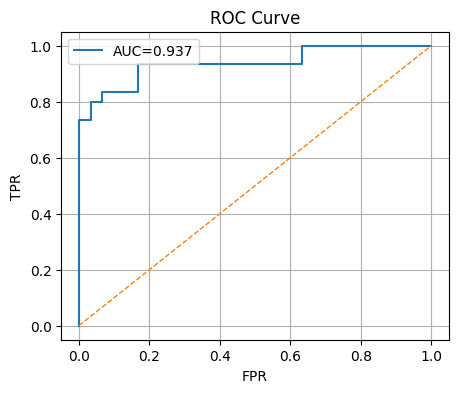

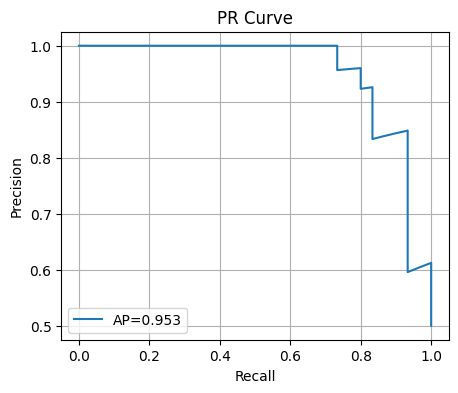

In [ ]:
y_true, y_prob = [], []
with torch.no_grad():
    for imgs, labels in tqdm(val_loader, desc="Val Eval"):
        imgs = imgs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        logits = best_model(imgs)
        probs = torch.sigmoid(logits).cpu().numpy().ravel()
        y_prob.extend(probs.tolist())
        y_true.extend(labels.cpu().numpy().ravel().tolist())

y_true = np.array(y_true); y_prob = np.array(y_prob)

# Best threshold by F1 grid search
ths = np.linspace(0.05, 0.95, 19)
best = None
for t in ths:
    m = {
        "thr": t,
        "f1": f1_score(y_true, (y_prob >= t).astype(int), zero_division=0),
        "acc": accuracy_score(y_true, (y_prob >= t).astype(int))
    }
    if best is None or m["f1"] > best["f1"]:
        best = m

print("Best threshold on VAL:", best)

y_pred = (y_prob >= best["thr"]).astype(int)
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix @thr=", best["thr"], "\n", cm)

print("\nClassification report @best thr:\n")
print(classification_report(y_true, y_pred, digits=3))

# ROC & PR curves
fpr, tpr, _ = roc_curve(y_true, y_prob)
prec, rec, _ = precision_recall_curve(y_true, y_prob)
auc = roc_auc_score(y_true, y_prob)
ap  = average_precision_score(y_true, y_prob)

plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f"AUC={auc:.3f}")
plt.plot([0,1],[0,1],'--',linewidth=1)
plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("ROC Curve"); plt.legend(); plt.grid(True); plt.show()

plt.figure(figsize=(5,4))
plt.plot(rec, prec, label=f"AP={ap:.3f}")
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("PR Curve"); plt.legend(); plt.grid(True); plt.show()


In [13]:
def area_bucket(a):
    if a < 32*32:    return "XS"
    if a < 64*64:    return "S"
    if a < 128*128:  return "M"
    if a < 256*256:  return "L"
    return "XL"

val_df_eval = val_df.copy().reset_index(drop=True)
val_df_eval["area_bucket"] = val_df_eval["area"].apply(area_bucket)
val_df_eval["y_true"] = y_true
val_df_eval["y_prob"] = y_prob
val_df_eval["y_pred"] = (y_prob >= best["thr"]).astype(int)

summary = []
for buk, grp in val_df_eval.groupby("area_bucket"):
    yt = grp["y_true"].values
    yp = grp["y_prob"].values
    yhat = grp["y_pred"].values
    if len(yt) == 0:
        continue
    m = {
        "bucket": buk,
        "n": len(yt),
        "acc": accuracy_score(yt, yhat),
        "f1": f1_score(yt, yhat, zero_division=0),
        "auc": roc_auc_score(yt, yp) if len(np.unique(yt)) > 1 else np.nan,
        "ap":  average_precision_score(yt, yp) if len(np.unique(yt)) > 1 else np.nan
    }
    summary.append(m)

pd.DataFrame(summary).sort_values("n", ascending=False)


,bucket,n,acc,f1,auc,ap
0,XL,60,0.883333,0.877193,0.936667,0.953054


In [ ]:
rows_te = []

def _rows_from_testing_json(test_json_path: Path):
    js = load_json(test_json_path)
    images_te = js.get("images", js if isinstance(js, dict) else [])
    out = []
    for im in images_te:
        fn = im.get("file_name") or im.get("filename") or im.get("name")
        if not fn:
            continue
        p = find_image_path(fn)
        if p is None:
            continue
        with Image.open(p) as img:
            if img.mode not in ("RGB", "L"):
                img = img.convert("RGB")
            elif img.mode == "L":
                img = img.convert("RGB")
            w, h = img.size
        out.append({
            "image_id": im.get("id", im.get("image_id", None)),
            "file_name": Path(fn).name,
            "path": str(p),
            "img_w": w,
            "img_h": h,
            "bbox_xywh": [0.0, 0.0, float(w), float(h)],
            "bbox_xyxy": (0.0, 0.0, float(w), float(h)),
            "ann_id": None,
        })
    return out

def _rows_from_patch_dir(patch_dir: Path, exclude_filenames=None):
    ex = set(exclude_filenames or [])
    out = []
    for p in sorted(patch_dir.glob("*")):
        if not p.is_file():
            continue
        if p.suffix.lower() not in {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}:
            continue
        fn = p.name
        if fn in ex:
            continue
        with Image.open(p) as img:
            if img.mode not in ("RGB", "L"):
                img = img.convert("RGB")
            elif img.mode == "L":
                img = img.convert("RGB")
            w, h = img.size
        out.append({
            "image_id": None,
            "file_name": fn,
            "path": str(p),
            "img_w": w,
            "img_h": h,
            "bbox_xywh": [0.0, 0.0, float(w), float(h)],
            "bbox_xyxy": (0.0, 0.0, float(w), float(h)),
            "ann_id": None,
        })
    return out

if TEST_JSON.exists():
    try:
        rows_te = _rows_from_testing_json(TEST_JSON)
    except Exception as e:
        print(f"Warnung: testing.json konnte nicht genutzt werden ({e}). Fallback auf PATCH_DIR.")
        rows_te = _rows_from_patch_dir(PATCH_DIR, exclude_filenames=set(df["file_name"].tolist()))
else:
    rows_te = _rows_from_patch_dir(PATCH_DIR, exclude_filenames=set(df["file_name"].tolist()))

test_df = pd.DataFrame(rows_te)
print("Test patches:", len(test_df))
test_df.head()


Test patches: 2607


,image_id,file_name,path,img_w,img_h,bbox_xywh,bbox_xyxy,ann_id
0,13,13.png,images0/13.png,1000,1000,"[0.0, 0.0, 1000.0, 1000.0]","(0.0, 0.0, 1000.0, 1000.0)",None
1,15,15.png,images4/15.png,1000,1000,"[0.0, 0.0, 1000.0, 1000.0]","(0.0, 0.0, 1000.0, 1000.0)",None
2,16,16.png,images5/16.png,1000,1000,"[0.0, 0.0, 1000.0, 1000.0]","(0.0, 0.0, 1000.0, 1000.0)",None
3,17,17.png,images2/17.png,1000,1000,"[0.0, 0.0, 1000.0, 1000.0]","(0.0, 0.0, 1000.0, 1000.0)",None
4,21,21.png,images2/21.png,1000,1000,"[0.0, 0.0, 1000.0, 1000.0]","(0.0, 0.0, 1000.0, 1000.0)",None


In [ ]:
class BoxTestDataset(Dataset):
    def __init__(self, df, transforms, crop_expand=0.10):
        self.df = df.reset_index(drop=True)
        self.transforms = transforms
        self.crop_expand = float(crop_expand)

    def __len__(self):
        return len(self.df)

    def _safe_open(self, path: str) -> Image.Image:
        im = Image.open(path)
        if im.mode not in ("RGB", "L"):
            im = im.convert("RGB")
        elif im.mode == "L":
            im = im.convert("RGB")
        return im

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        im = self._safe_open(row["path"])
        img_w, img_h = im.size

        x1, y1, x2, y2 = row["bbox_xyxy"]
        x1, y1, x2, y2 = expand_box((x1, y1, x2, y2), img_w, img_h, expand=self.crop_expand)
        x1, y1, x2, y2 = clip_box((x1, y1, x2, y2), img_w, img_h)

        crop = im.crop((x1, y1, x2, y2))
        crop_np = np.array(crop)
        aug = self.transforms(image=crop_np)

        ann_id = row.get("ann_id", None)
        return aug["image"], row["file_name"], row["bbox_xywh"], ann_id

def collate_allow_none(batch):
    imgs, fns, bboxes, ann_ids = zip(*batch)
    return torch.stack(imgs, 0), list(fns), list(bboxes), list(ann_ids)

test_ds = BoxTestDataset(test_df, transforms=val_tfms, crop_expand=CROP_EXPAND)
test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    collate_fn=collate_allow_none,   
)

pred_rows = []
best_model.eval()
with torch.no_grad():
    for imgs, fns, bboxes, ann_ids in tqdm(test_loader, desc="Inference"):
        imgs = imgs.to(DEVICE, non_blocking=True)
        logits = best_model(imgs)
        probs = torch.sigmoid(logits).cpu().numpy().ravel()

        for fn, bb, a_id, p in zip(fns, bboxes, ann_ids, probs):
            bb = [float(x) for x in bb]  
            a_id_out = (int(a_id) if a_id is not None else None)
            pred_rows.append({
                "file_name": fn,
                "ann_id": a_id_out,
                "bbox_x": bb[0], "bbox_y": bb[1], "bbox_w": bb[2], "bbox_h": bb[3],
                "waste_proba": float(p),
                "waste_pred": int(p >= best["thr"])
            })

pred_df = pd.DataFrame(pred_rows)
pred_df.to_csv(PRED_CSV, index=False)
print("Saved:", PRED_CSV)
pred_df.head()

Inference: 100%|██████████| 163/163 [01:52<00:00,  1.45it/s]

Saved: test_predictions_boxclf.csv


,file_name,ann_id,bbox_x,bbox_y,bbox_w,bbox_h,waste_proba,waste_pred
0,13.png,None,0.0,0.0,1000.0,1000.0,0.090815,0
1,15.png,None,0.0,0.0,1000.0,1000.0,0.449155,0
2,16.png,None,0.0,0.0,1000.0,1000.0,0.380427,0
3,17.png,None,0.0,0.0,1000.0,1000.0,0.397917,0
4,21.png,None,0.0,0.0,1000.0,1000.0,0.247112,0


In [16]:
def draw_boxes_on_image(path: str, boxes_probs_labels: List[Tuple[Tuple[float,float,float,float], float, int, int]]):
    """
    Draw color-coded boxes for qualitative review.

    Args:
        path: path to the original image.
        boxes_probs_labels: list of tuples: ((x1,y1,x2,y2), prob, y_true, y_pred).

    Returns:
        PIL.Image with rectangles and text overlays.
    """
    im = Image.open(path).convert("RGB")
    draw = ImageDraw.Draw(im)
    for (x1,y1,x2,y2), prob, yt, yp in boxes_probs_labels:
        if yt==1 and yp==1:
            color = (0,200,0)    # True Positive
        elif yt==0 and yp==1:
            color = (220,50,50)  # False Positive
        elif yt==1 and yp==0:
            color = (255,140,0)  # False Negative
        else:
            color = (80,80,80)   # True Negative
        draw.rectangle([x1,y1,x2,y2], outline=color, width=3)
        draw.text((x1+3, max(0,y1-12)), f"{prob:.2f}", fill=color)
    return im

def show_image_grid(images: List[Image.Image], cols=4, title=None, max_images=16, size=(256,256)):
    """
    Display a grid of images (optionally resized) for quick scanning.

    Args:
        images: list of PIL.Image objects
        cols: number of columns
        title: optional figure title
        max_images: cap the number of images rendered
        size: resize each tile to this (w,h)
    """
    images = images[:max_images]
    rows = math.ceil(len(images)/cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols*3, rows*3))
    if title:
        fig.suptitle(title)
    axes = np.array(axes).reshape(-1) if isinstance(axes, np.ndarray) else [axes]
    for ax, im in zip(axes, images):
        ax.imshow(im.resize(size))
        ax.axis("off")
    # Hide unused axes
    for ax in axes[len(images):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

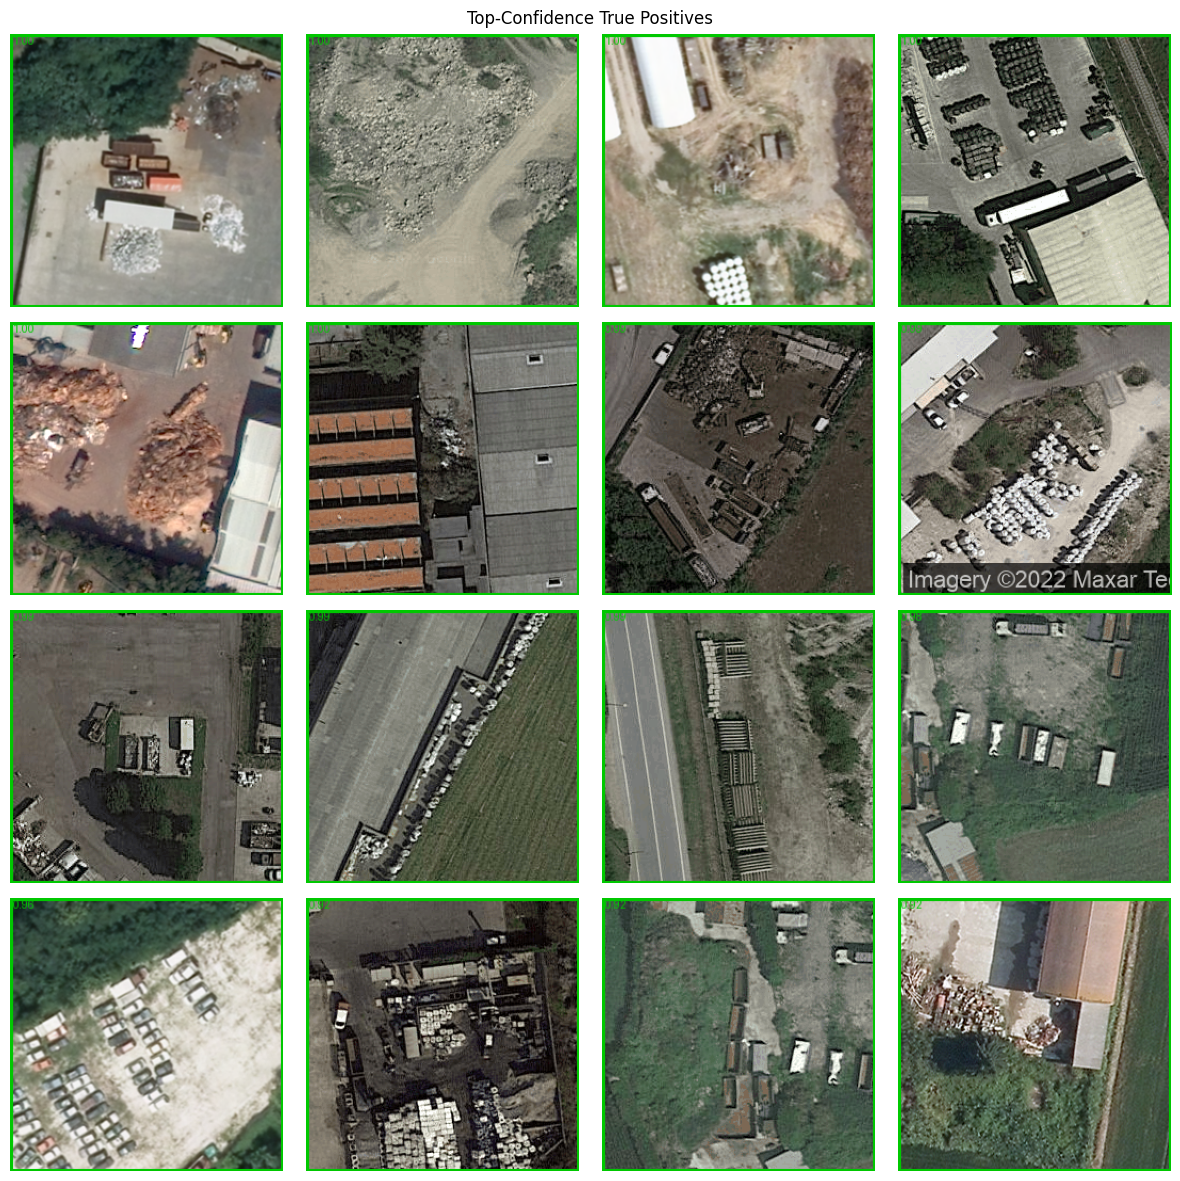

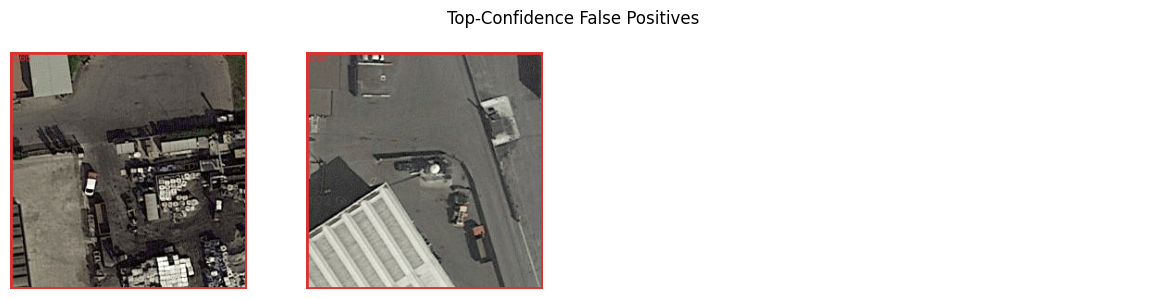

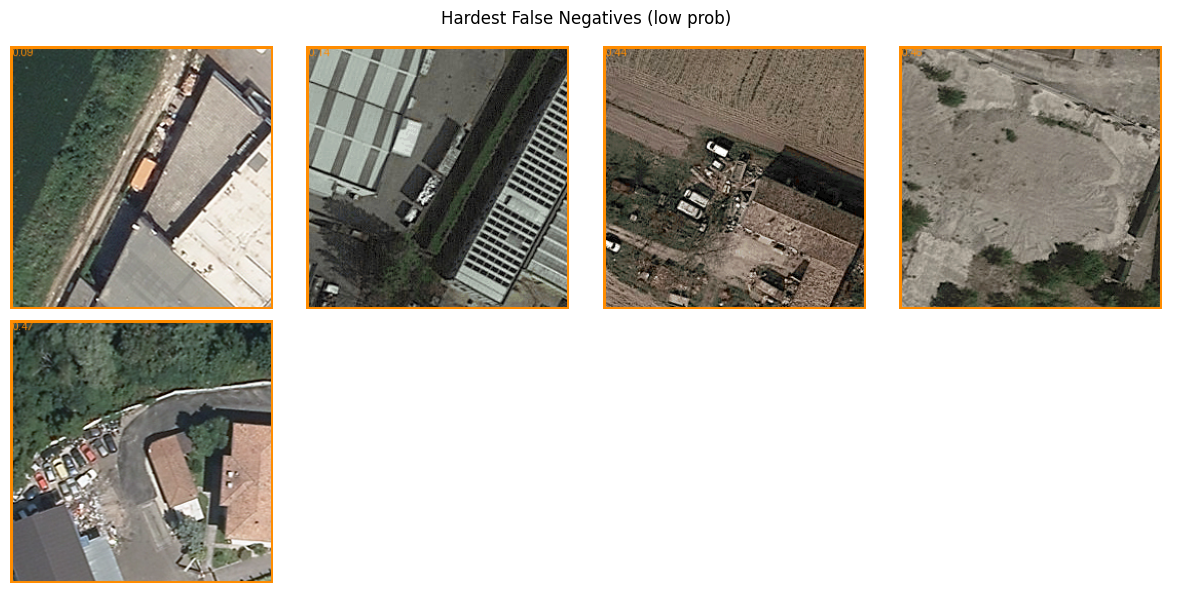

In [17]:
val_pred_df = val_df.copy().reset_index(drop=True)
val_pred_df["y_true"] = y_true
val_pred_df["y_prob"] = y_prob
val_pred_df["y_pred"] = (y_prob >= best["thr"]).astype(int)

def collect_examples(df, kind="TP", k=16):
    """
    Select representative examples to visualize.
    - TP: sort by highest probability
    - FP: sort by highest probability
    - FN: sort by lowest probability (hard misses)
    """
    if kind == "TP":
        sel = df[(df.y_true==1) & (df.y_pred==1)].copy()
        sel = sel.sort_values("y_prob", ascending=False)
    elif kind == "FP":
        sel = df[(df.y_true==0) & (df.y_pred==1)].copy()
        sel = sel.sort_values("y_prob", ascending=False)
    elif kind == "FN":
        sel = df[(df.y_true==1) & (df.y_pred==0)].copy()
        sel = sel.sort_values("y_prob", ascending=True)
    else:
        sel = df.sample(n=min(k, len(df)))
    return sel.head(k)

def render_examples(rows):
    """Create PIL images with a single colored box per selected row."""
    ims = []
    for _, r in rows.iterrows():
        path = r["path"]
        xyxy = r["bbox_xyxy"]
        im = draw_boxes_on_image(
            path,
            boxes_probs_labels=[(xyxy, r["y_prob"], int(r["y_true"]), int(r["y_pred"]))]
        )
        ims.append(im)
    return ims

tp_rows = collect_examples(val_pred_df, "TP", k=16)
fp_rows = collect_examples(val_pred_df, "FP", k=16)
fn_rows = collect_examples(val_pred_df, "FN", k=16)

tp_ims = render_examples(tp_rows)
fp_ims = render_examples(fp_rows)
fn_ims = render_examples(fn_rows)

show_image_grid(tp_ims, cols=4, title="Top-Confidence True Positives")
show_image_grid(fp_ims, cols=4, title="Top-Confidence False Positives")
show_image_grid(fn_ims, cols=4, title="Hardest False Negatives (low prob)")


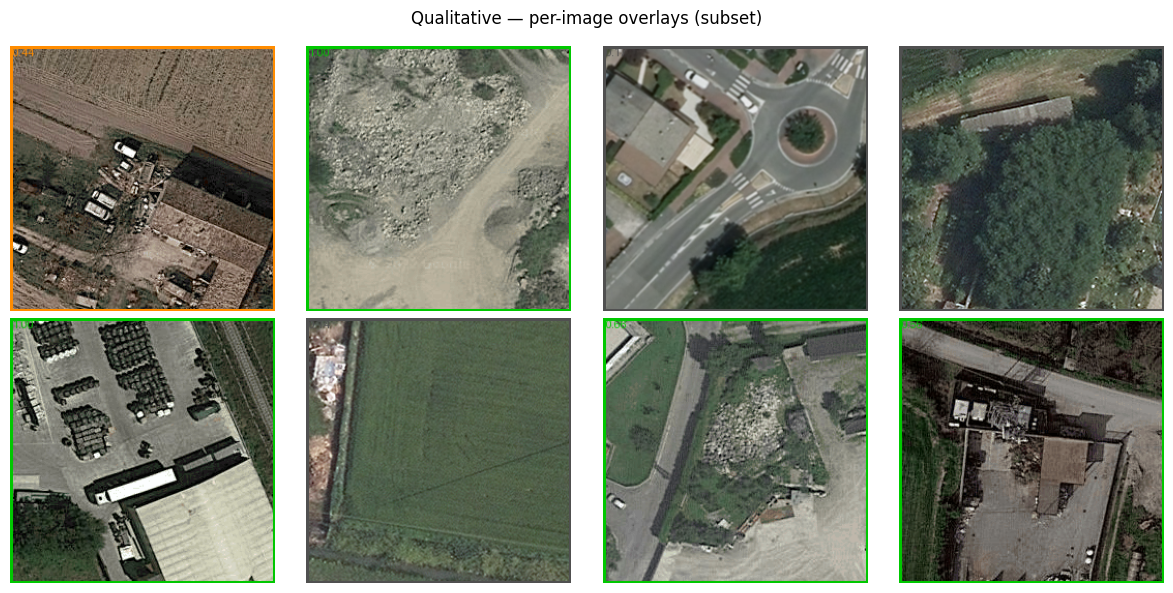

In [18]:
def group_val_predictions_by_image(df_with_preds):
    """
    Group per-box predictions by 'path' (image file).
    Returns: dict[path] -> list[((x1,y1,x2,y2), prob, y_true, y_pred), ...]
    """
    g = {}
    for _, r in df_with_preds.iterrows():
        key = r["path"]
        if key not in g: g[key] = []
        g[key].append((
            tuple(r["bbox_xyxy"]),
            float(r["y_prob"]),
            int(r["y_true"]),
            int(r["y_pred"])
        ))
    return g

grouped = group_val_predictions_by_image(val_pred_df)
sample_keys = list(grouped.keys())[:8] if len(grouped) > 8 else list(grouped.keys())

ims = []
for k in sample_keys:
    ims.append(draw_boxes_on_image(k, grouped[k]))

show_image_grid(ims, cols=4, title="Qualitative — per-image overlays (subset)")


In [19]:
OUT_DIR = Path("qualitative_panels")
OUT_DIR.mkdir(parents=True, exist_ok=True)

def save_grid(images, name="grid.png", cols=4, size=(256,256)):
    """
    Save an image grid without using matplotlib (pure PIL).
    Args:
        images: list of PIL.Image
        name: filename in OUT_DIR
        cols: number of columns
        size: tile size (width, height)
    """
    rows = math.ceil(len(images)/cols)
    w, h = size
    canvas = Image.new("RGB", (cols*w, rows*h), color=(20,20,20))
    for i, im in enumerate(images):
        r, c = divmod(i, cols)
        canvas.paste(im.resize(size), (c*w, r*h))
    out_path = OUT_DIR / name
    canvas.save(out_path)
    return out_path

p_tp = save_grid(tp_ims, "TP_grid.png")
p_fp = save_grid(fp_ims, "FP_grid.png")
p_fn = save_grid(fn_ims, "FN_grid.png")
print("Saved panels:", p_tp, p_fp, p_fn)


Saved panels: qualitative_panels/TP_grid.png qualitative_panels/FP_grid.png qualitative_panels/FN_grid.png


In [ ]:
if "area" not in val_pred_df.columns:
    if {"bbox_w", "bbox_h"}.issubset(val_pred_df.columns):
        val_pred_df["area"] = val_pred_df["bbox_w"] * val_pred_df["bbox_h"]
    elif "bbox_xywh" in val_pred_df.columns:
        val_pred_df["area"] = val_pred_df["bbox_xywh"].apply(
            lambda b: float(b[2]) * float(b[3]) if isinstance(b, (list, tuple, np.ndarray)) and len(b) == 4
            else np.nan
        )
    else:
        if {"img_w", "img_h"}.issubset(val_pred_df.columns):
            val_pred_df["area"] = val_pred_df["img_w"] * val_pred_df["img_h"]
        else:
            val_pred_df["area"] = np.nan

if "area_bucket" not in val_pred_df.columns:
    try:
        val_pred_df["area_bucket"] = pd.qcut(
            val_pred_df["area"], q=4,
            labels=["Q1_small", "Q2_mid", "Q3_big", "Q4_huge"]
        )
    except ValueError:
        val_pred_df["area_bucket"] = "all"

overall = {
    "split": "val_overall",
    "n": len(val_pred_df),
    "thr": best["thr"],
    "acc": accuracy_score(y_true, y_pred),
    "f1": f1_score(y_true, y_pred, zero_division=0),
    "auc": roc_auc_score(y_true, y_prob),
    "ap": average_precision_score(y_true, y_prob),
}

by_bucket = []
for buk, grp in val_pred_df.groupby("area_bucket"):
    yt = grp["y_true"].values
    yp = grp["y_prob"].values
    yhat = grp["y_pred"].values
    if len(yt) == 0: continue
    row = {
        "split": f"val_{buk}",
        "n": len(yt),
        "thr": best["thr"],
        "acc": accuracy_score(yt, yhat),
        "f1": f1_score(yt, yhat, zero_division=0),
        "auc": roc_auc_score(yt, yp) if len(np.unique(yt))>1 else np.nan,
        "ap": average_precision_score(yt, yp) if len(np.unique(yt))>1 else np.nan,
    }
    by_bucket.append(row)

metrics_df = pd.DataFrame([overall] + by_bucket)
metrics_df.to_csv("val_metrics_boxclf.csv", index=False)
metrics_df

,split,n,thr,acc,f1,auc,ap
0,val_overall,60,0.55,0.883333,0.877193,0.936667,0.953054
1,val_all,60,0.55,0.883333,0.877193,0.936667,0.953054
